#### **Transformer**

##### **Evolution of Sequence Models**

1. **RNN** (Recurrent Neural Network)  
   → Basic sequential processing with hidden states

2. **LSTM** (Long Short-Term Memory)  
   → Improved RNN with gates to handle long-term dependencies

3. **GRU** (Gated Recurrent Unit)  
   → Simplified LSTM with fewer parameters

4. **Encoder/Decoder**  
   → Separate networks for encoding input and decoding output

   → The architecture was still LSTM 

5. **Encoder/Decoder with Attention**  
   → Added attention mechanism for better alignment

   → The architecture was still LSTM

6. **ULMFIT** (Universal Language Model Fine-tuning)  
   → Transfer learning approach for NLP tasks

   → The architecture was still LSTM and later on Fine tuning was done on the initally LSTM based model.

   → Scalability issues because of sequential training

7. **Transformer**  
   → Attention-only architecture with parallel processing


LSTM had a major drawback because of which we were not able to scale the "Large" data for Natural language text processing. 

Language modelling was first dicussed in ULMFIT reserach paper which was again based on LSTM which was not again scalable. 

Later there was reserach on Transformer and then we got the concepts of self attention because of which we were able to pass the data in parallel contrary to the earlier sequential data passing. This is how we were able to model the data on large dataset. 

##### **Introduction to Transformers**

Transformers are a type of neural network architecture introduced in the paper "Attention is All You Need". They revolutionized natural language processing by replacing recurrent neural networks (RNNs) with attention mechanisms.

A transformer has 2 parts: 
- **Encoder** (BERT was based on encoder)
- **Decoder** (GPT is based on Decoder)


**Most new age LLMs like GPT, LLama, Mistral, Deepseek, Qwen (Open Source), Claude models(Opus, Haiku, Sonnet) , Gemini are based on Decoder part of the transformer.**


https://jalammar.github.io/illustrated-transformer/

Originally Encoder Decoder architecture was made for machine translation. 

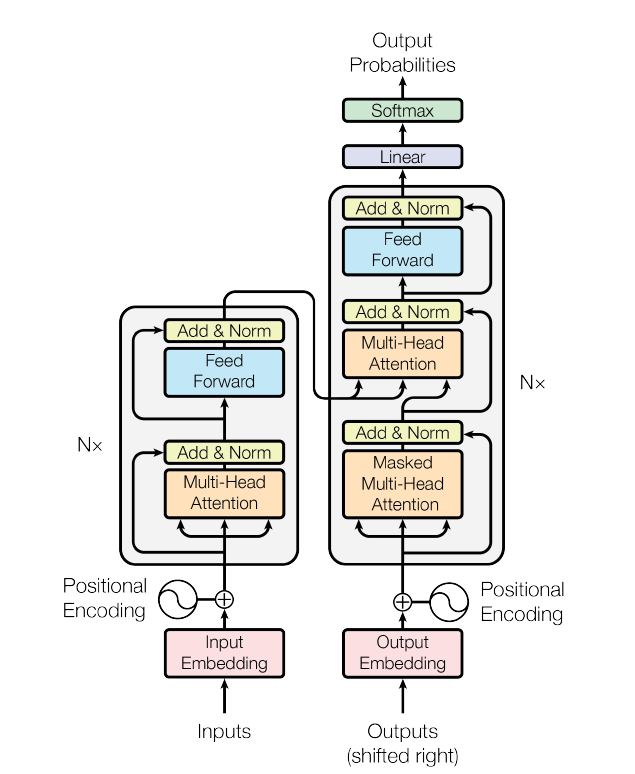

In [2]:
from IPython.display import Image, display
display(Image(filename='Research/Transformer.png'))


**Components of Encoder:** 
- Input sequence : Parallely we give the data in the form of tokens by doing the process of tokenisation. We give all the tokens together in parallel (single shot) to the model for embedding
- Input embeddings : we convert into embeddings using word2vec(model dimension = 512)
- **Positional encoding** : to sustain the sequence of data
- **Self-attention (Multi-head attention)** : Query, Key, Value explained below. Here we do linear transformation of data to extract the info
- Add & layer Normalisation
- **Feed Forward network (ANN)**
- **Residual connection + Layer Normalisation**
- Repeat encoder block N times (same process in each block): In paper they kept 6 blocks. We can have as many as we need. 

Data => Tokenisation => embedding => Positional encoding => Self-attention layer => normalisation => Feed forward neural network

This is then passed on to decoder side. 

**Components of Decoder:** 
- Output sequence (shifted right)
- Output sequence embeddings (dimension ~512)
- Positional encoding
- Masked Multi head attention
- Add & layer Normalisation
- Residual connection
- Cross attention (encoder+decoder interaction)
- Add & layer Normalisation
- Feed Forward network (ANN)
- Add & layer Normalisation
- Linear Layer
- Softmax
- Final Output(probabilities)
- Repeat decoder block multiple times


All the steps above are used in the training phase of the model. 
This is separate from the inferencing phase of the models. 

# RNN/LSTM vs Transformer Comparison

| Aspect | RNN/LSTM | Transformer |
|--------|----------|-------------|
| **Processing** | Sequential (one element at a time) | Parallel (entire sequence at once) |
| **Training Efficiency** | Slower; can't leverage GPUs fully | Faster; optimized for GPUs |
| **Dependencies** | Short-term; struggles with long sentences (vanishing context) | Long-range; excels via self-attention |
| **Architecture** | Hidden state with recurrence | Encoder-decoder with multi-head attention, position encodings |
| **Parallelization** | Limited; sequential computations | Highly parallelizable |
| **Scalability** | Limited for very long sequences | Scales well to large models and datasets |
| **Examples** | LSTMs for sequence prediction | BERT, GPT for NLP tasks |
| **Computational Resources** | Lower requirements | Higher; needs more data and compute |
| **Introduced** | RNNs: 1980s; LSTMs: 1997 | 2017 ("Attention is All You Need") |


### Key Advantages:
- **Parallelization**: Unlike RNNs, transformers can process entire sequences in parallel
- **Long-range dependencies**: Attention mechanism captures relationships between any two positions in the sequence
- **Scalability**: Easier to train on large datasets and scale to longer sequences

### Core Components:
1. **Self-Attention Mechanism**
2. **Multi-Head Attention**
3. **Positional Encoding**
4. **Feed-Forward Networks**
5. **Layer Normalization and Residual Connections**

#### **Self-Attention Mechanism**

Self-attention allows the model to weigh the importance of different words in a sequence when encoding a particular word.
Because of self-attention, we can generate dynamic embeddings i.e. the embedding for apple(phone) and apple(fruit) will be different when they are present in a sentence.

##### How it works:
1. **Query, Key, Value vectors**: Each input word is transformed into three vectors
   - Query (Q): What I'm looking for
   - Key (K): What I can offer
   - Value (V): The actual information

2. **Attention Scores**: Compute similarity between Query and all Keys using dot-product
   - `attention_score = Q · K^T / sqrt(d_k)`

3. **Softmax**: Convert scores to probabilities (weights)

4. **Weighted Sum**: Multiply weights with Values to get context vector
   - `context = softmax(attention_scores) · V`

##### Scaled Dot-Product Attention Formula:
```
Attention(Q, K, V) = softmax((Q·K^T)/√d_k) · V
```

**Interview Tip**: Self-attention is O(n²) in time and space complexity, making it expensive for very long sequences.

## Multi-Head Attention

Multi-head attention runs multiple self-attention mechanisms in parallel, allowing the model to capture different types of relationships.

### Why Multi-Head?
- **Different representation subspaces**: Each head learns different aspects of the relationships
- **Improved expressiveness**: Concatenating multiple attention heads provides richer representations

### Process:
1. **Linear projections**: Create multiple sets of Q, K, V for each head
   - `Q_i = X · W^Q_i`, `K_i = X · W^K_i`, `V_i = X · W^V_i`

2. **Parallel attention**: Compute attention for each head independently

3. **Concatenate**: Combine outputs from all heads
   - `MultiHead(Q, K, V) = Concat(head_1, ..., head_h) · W^O`

### Benefits:
- Allows model to jointly attend to information from different representation subspaces
- Typically uses 8-16 heads in practice

**Interview Tip**: Multi-head attention helps the model learn different types of dependencies (e.g., syntactic vs. semantic).

## Positional Encoding

Since transformers don't have recurrence, they need a way to understand word order. Positional encoding injects position information into the input embeddings.

### Why needed?
- Self-attention is permutation-invariant (order doesn't matter)
- But word order is crucial in language

### Sinusoidal Positional Encoding:
```
PE(pos, 2i) = sin(pos / 10000^(2i/d_model))
PE(pos, 2i+1) = cos(pos / 10000^(2i/d_model))
```

### Properties:
- **Unique for each position**: Different positions get different encodings
- **Relative positioning**: The difference between PE(pos+k) and PE(pos) depends only on k
- **Extrapolation**: Can handle sequences longer than seen during training

### Alternative: Learned Positional Embeddings
- Simply learn position embeddings like word embeddings
- More flexible but can't extrapolate to longer sequences

**Interview Tip**: Positional encoding is added to input embeddings before the first attention layer.

## Encoder-Decoder Architecture

The Transformer consists of an encoder (for understanding input) and a decoder (for generating output).

### Encoder:
- **N identical layers** (typically N=6)
- Each layer has:
  1. **Multi-Head Self-Attention**
  2. **Feed-Forward Network**
  3. **Residual connections** around each sub-layer
  4. **Layer normalization**

### Decoder:
- **N identical layers** (typically N=6)
- Each layer has:
  1. **Masked Multi-Head Self-Attention** (prevents attending to future tokens)
  2. **Multi-Head Cross-Attention** (attends to encoder output)
  3. **Feed-Forward Network**
  4. **Residual connections and layer normalization**

### Key Differences:
- **Encoder**: Only self-attention (bidirectional)
- **Decoder**: Masked self-attention (unidirectional) + cross-attention to encoder

**Interview Tip**: The encoder processes the entire input sequence at once, while the decoder generates output autoregressively.

## Training and Inference

### Training:
- **Teacher Forcing**: During training, decoder receives ground-truth previous tokens
- **Masked Self-Attention**: In decoder, future tokens are masked to prevent cheating
- **Label Smoothing**: Applied to output probabilities for better generalization
- **Learning Rate Schedule**: Warmup followed by inverse square root decay

### Inference:
- **Autoregressive Generation**: Generate one token at a time
- **Beam Search**: Keep top-k most likely sequences (vs greedy decoding)
- **Temperature Sampling**: Control randomness in generation

### Loss Function:
- **Cross-Entropy Loss**: Between predicted and target token distributions
- **Masked Language Modeling**: For BERT-style pre-training

**Interview Tip**: During inference, the decoder attends to previously generated tokens, not ground truth.

## Variants and Applications

### Encoder-Only Models:
- **BERT (Bidirectional Encoder Representations from Transformers)**: Pre-trained on masked language modeling
- **RoBERTa, ALBERT, DistilBERT**: Improvements and optimizations of BERT

### Decoder-Only Models:
- **GPT series (GPT-1, GPT-2, GPT-3, GPT-4)**: Generative Pre-trained Transformers
- **LLaMA, PaLM**: Large language models for text generation

### Encoder-Decoder Models:
- **T5 (Text-to-Text Transfer Transformer)**: Unified framework for NLP tasks
- **BART**: Denoising autoencoder for generation tasks

### Vision Transformers (ViT):
- Apply transformer architecture to image patches
- Compete with convolutional networks on image classification

### Applications:
- **Machine Translation**: Original use case
- **Text Summarization**
- **Question Answering**
- **Text Classification**
- **Code Generation**
- **Chatbots and Conversational AI**

**Interview Tip**: BERT uses bidirectional context, while GPT uses unidirectional (left-to-right).

## Key Interview Questions & Answers

### Q: What is the main advantage of Transformers over RNNs?
**A**: Transformers can process sequences in parallel, unlike RNNs which process sequentially. This makes them much faster to train and allows them to capture long-range dependencies more effectively.

### Q: Explain self-attention in simple terms.
**A**: Self-attention allows each word in a sentence to look at all other words and determine how important each is for understanding the current word. It's like each word voting on which other words are most relevant to its meaning.

### Q: Why do we need positional encoding?
**A**: Because self-attention treats words as a set (order doesn't matter), but word order is crucial in language. Positional encoding gives the model information about where each word appears in the sequence.

### Q: What's the difference between encoder and decoder in Transformers?
**A**: The encoder processes the input sequence and creates a rich representation. The decoder generates the output sequence, using cross-attention to look at the encoder's output while using masked self-attention to avoid looking at future tokens.

### Q: How does multi-head attention work?
**A**: It runs multiple attention mechanisms in parallel, each learning different types of relationships between words. The outputs are concatenated and linearly transformed to create a richer representation.

### Q: What are the computational complexities?
**A**: Self-attention is O(n²) in time and space for sequence length n, making it expensive for very long sequences. This is why there are optimizations like sparse attention or linear attention.

### Q: How do Transformers handle variable-length sequences?
**A**: Through padding and masking. Shorter sequences are padded to match the longest, and attention masks prevent the model from attending to padding tokens.

### Q: What's the role of layer normalization and residual connections?
**A**: Residual connections help with gradient flow during training, preventing vanishing gradients. Layer normalization stabilizes training by normalizing activations within each layer.

**Remember**: Focus on understanding the "why" behind each component, not just memorizing formulas.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class SimpleSelfAttention(nn.Module):
    def __init__(self, embed_size, heads):
        super(SimpleSelfAttention, self).__init__()
        self.embed_size = embed_size
        self.heads = heads
        self.head_dim = embed_size // heads

        assert (self.head_dim * heads == embed_size), "embed_size must be divisible by heads"

        self.values = nn.Linear(embed_size, embed_size, bias=False)
        self.keys = nn.Linear(embed_size, embed_size, bias=False)
        self.queries = nn.Linear(embed_size, embed_size, bias=False)
        self.fc_out = nn.Linear(embed_size, embed_size)

    def forward(self, x):
        N, seq_length, embed_size = x.shape

        # Split into heads
        values = self.values(x).view(N, seq_length, self.heads, self.head_dim)
        keys = self.keys(x).view(N, seq_length, self.heads, self.head_dim)
        queries = self.queries(x).view(N, seq_length, self.heads, self.head_dim)

        # Attention mechanism
        energy = torch.einsum("nqhd,nkhd->nhqk", [queries, keys])
        attention = F.softmax(energy / (self.embed_size ** (1/2)), dim=3)

        out = torch.einsum("nhql,nlhd->nqhd", [attention, values]).reshape(
            N, seq_length, self.heads * self.head_dim
        )

        out = self.fc_out(out)
        return out

# Example usage
embed_size = 256
heads = 8
seq_length = 10
batch_size = 1

model = SimpleSelfAttention(embed_size, heads)
x = torch.randn(batch_size, seq_length, embed_size)
output = model(x)
print(f"Input shape: {x.shape}")
print(f"Output shape: {output.shape}")

Input shape: torch.Size([1, 10, 256])
Output shape: torch.Size([1, 10, 256])


## Interview Preparation Tips

### Common Mistakes to Avoid:
1. **Confusing self-attention with cross-attention**: Self-attention is within the same sequence, cross-attention is between different sequences (e.g., decoder attending to encoder)

2. **Forgetting masking**: In decoder, future tokens must be masked during training

3. **Ignoring computational complexity**: O(n²) scaling is a major limitation

4. **Not understanding pre-training vs fine-tuning**: Models like BERT are pre-trained on large corpora then fine-tuned for specific tasks

### Key Papers to Know:
- **"Attention is All You Need" (2017)**: Original transformer paper
- **"BERT: Pre-training of Deep Bidirectional Transformers" (2018)**
- **"Language Models are Few-Shot Learners" (2020)**: GPT-3 paper

### Practice Problems:
- Implement scaled dot-product attention from scratch
- Explain how positional encoding works mathematically
- Compare transformers vs RNNs vs CNNs for sequence modeling
- Discuss how you'd modify transformers for different modalities (vision, audio)

### Final Advice:
- Draw diagrams when explaining concepts
- Use analogies (attention as "voting" or "looking up information")
- Be ready to discuss trade-offs and limitations
- Understand the big picture: transformers are just one tool in the ML toolbox

Good luck with your interviews! 🚀

# RNN/LSTM vs Transformer Comparison

| Aspect | RNN/LSTM | Transformer |
|--------|----------|-------------|
| **Processing** | Sequential (one element at a time) | Parallel (entire sequence at once) |
| **Dependencies** | Short-term; struggles with long-range (vanishing gradients) | Long-range; excels via self-attention, Ex: Sustains long contexts |
| **Architecture** | Hidden state with recurrence | Encoder-decoder with multi-head attention, position encodings |
| **Parallelization** | Limited; sequential computations | Highly parallelizable |
| **Training Efficiency** | Slower; can't leverage GPUs fully | Faster; optimized for GPUs |
| **Scalability** | Limited for very long sequences | Scales well to large models and datasets |
| **Examples** | LSTMs for sequence prediction | BERT, GPT for NLP tasks |
| **Computational Resources** | Lower requirements | Higher; needs more data and compute |
| **Introduced** | RNNs: 1980s; LSTMs: 1997 | 2017 ("Attention is All You Need") |



It is difficult to train LSTM on large amount of data which formed the basis for the need of LLM. 

Language modelling is the process of prediction of next token. 

They took large internet data, the early stage LLM was BERT, GPT 1,2,3 based on Transformer architecture